# 01. Exploratory Data Analysis & Data Cleaning
**Project:** Car Price Prediction (Otomoto Dataset)  
**Goal:** Analyze data distributions, handle missing values and potentioal duplicates.

## 1. Imports and environment setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## 2. Configuration and Paths

In [3]:
BASE_PATH = Path.cwd().parent
RAW_DATA_PATH = BASE_PATH / "data" / "raw" / "Car_sale_ads.csv"

## 3. Data Loading

In [4]:
df_raw = pd.read_csv(RAW_DATA_PATH)
df_raw.head(20)

,Index,Price,Currency,Condition,Vehicle_brand,Vehicle_model,Vehicle_version,Vehicle_generation,Production_year,Mileage_km,...,Transmission,Type,Doors_number,Colour,Origin_country,First_owner,First_registration_date,Offer_publication_date,Offer_location,Features
0,0,86200,PLN,New,Abarth,595,NaN,NaN,2021,1.0,...,Manual,small_cars,3.0,gray,NaN,NaN,NaN,04/05/2021,"ul. Jubilerska 6 - 04-190 Warszawa, Mazowiecki...",[]
1,1,43500,PLN,Used,Abarth,Other,NaN,NaN,1974,59000.0,...,Manual,coupe,2.0,silver,NaN,NaN,NaN,03/05/2021,"kanonierska12 - 04-425 Warszawa, Rembertów (Po...",[]
2,2,44900,PLN,Used,Abarth,500,NaN,NaN,2018,52000.0,...,Automatic,small_cars,3.0,silver,NaN,NaN,NaN,03/05/2021,"Warszawa, Mazowieckie, Białołęka","['ABS', 'Electric front windows', 'Drivers air..."
3,3,39900,PLN,Used,Abarth,500,NaN,NaN,2012,29000.0,...,Manual,small_cars,3.0,gray,NaN,NaN,NaN,30/04/2021,"Jaworzno, Śląskie","['ABS', 'Electric front windows', 'Drivers air..."
4,4,97900,PLN,New,Abarth,595,NaN,NaN,2021,600.0,...,Manual,small_cars,3.0,blue,NaN,NaN,NaN,30/04/2021,"ul. Gorzysława 9 - 61-057 Poznań, Nowe Miasto ...","['ABS', 'Electrically adjustable mirrors', 'Pa..."
5,5,62950,PLN,Used,Abarth,595,NaN,NaN,2016,46060.0,...,Manual,small_cars,3.0,gray,Germany,Yes,15/03/2016,30/04/2021,"Modlińska 157 - 03-186 Warszawa, Białołęka (Po...","['ABS', 'Electric front windows', 'Drivers air..."
6,6,69900,PLN,Used,Abarth,595,NaN,NaN,2021,2900.0,...,Manual,small_cars,2.0,black,Germany,NaN,25/02/2021,29/04/2021,"Żary, żarski, Lubuskie",[]
7,7,69900,PLN,Used,Abarth,500,NaN,NaN,2019,20000.0,...,Manual,small_cars,3.0,white,Poland,Yes,NaN,29/04/2021,"Ojcowska 2 - 02-918 Warszawa, Mokotów (Polska)","['ABS', 'Electrically adjustable mirrors', 'Pa..."
8,8,120750,PLN,New,Abarth,595,NaN,NaN,2021,1.0,...,Manual,small_cars,3.0,blue,NaN,NaN,NaN,03/05/2021,"ul. Gorzysława 9 - 61-057 Poznań, Nowe Miasto ...","['ABS', 'Electrically adjustable mirrors', 'Pa..."
9,9,93100,PLN,New,Abarth,595,NaN,NaN,2021,1.0,...,Manual,small_cars,3.0,gray,NaN,NaN,NaN,03/05/2021,"ul. Gorzysława 9 - 61-057 Poznań, Nowe Miasto ...","['ABS', 'Electrically adjustable mirrors', 'Pa..."


In [5]:
df_raw.shape

(208304, 25)

In [6]:
#general information about hte dataset

df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 208304 entries, 0 to 208303
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Index                    208304 non-null  int64  
 1   Price                    208304 non-null  int64  
 2   Currency                 208304 non-null  str    
 3   Condition                208304 non-null  str    
 4   Vehicle_brand            208304 non-null  str    
 5   Vehicle_model            208304 non-null  str    
 6   Vehicle_version          138082 non-null  str    
 7   Vehicle_generation       147860 non-null  str    
 8   Production_year          208304 non-null  int64  
 9   Mileage_km               207321 non-null  float64
 10  Power_HP                 207661 non-null  float64
 11  Displacement_cm3         206338 non-null  float64
 12  Fuel_type                208304 non-null  str    
 13  CO2_emissions            94047 non-null   float64
 14  Drive          

In [7]:
#Information about numerical columns

df_raw.describe()

,Index,Price,Production_year,Mileage_km,Power_HP,Displacement_cm3,CO2_emissions,Doors_number
count,208304.000000,2.083040e+05,208304.000000,2.073210e+05,207661.000000,206338.000000,9.404700e+04,206817.000000
mean,104151.500000,6.305383e+04,2012.098241,1.502768e+05,151.836281,1882.567147,3.191564e+05,4.637138
std,60132.329574,8.665967e+04,6.998414,2.937447e+06,77.683546,729.609660,7.291396e+07,0.768559
min,0.000000,5.000000e+02,1915.000000,1.000000e+00,1.000000,400.000000,1.000000e+00,1.000000
25%,52075.750000,1.780000e+04,2008.000000,5.300000e+04,105.000000,1461.000000,1.200000e+02,5.000000
50%,104151.500000,3.570000e+04,2013.000000,1.445660e+05,136.000000,1798.000000,1.400000e+02,5.000000
75%,156227.250000,7.599000e+04,2017.000000,2.060000e+05,172.000000,1997.000000,1.640000e+02,5.000000
max,208303.000000,6.999000e+06,2021.000000,1.111111e+09,1398.000000,8400.000000,2.000000e+10,55.000000


In [8]:
#Information about categorical columns

df_raw.describe(include = ['object', 'string'])

,Currency,Condition,Vehicle_brand,Vehicle_model,Vehicle_version,Vehicle_generation,Fuel_type,Drive,Transmission,Type,Colour,Origin_country,First_owner,First_registration_date,Offer_publication_date,Offer_location,Features
count,208304,208304,208304,208304,138082,147860,208304,193228,207825,208304,208304,118312,65094,86445,208304,208304,208304
unique,2,2,108,1203,19056,569,8,5,2,9,14,37,1,8441,41,13635,177211
top,PLN,Used,Volkswagen,Astra,2.0 TDI,II (2012-),Gasoline,Front wheels,Manual,SUV,black,Poland,Yes,01/01/2017,03/05/2021,"Stalowa 16 - 41-506 Chorzów, Śląskie (Polska)",[]
freq,208034,182850,18455,5302,888,3758,99352,139944,132889,41587,50355,57127,65094,216,26561,1329,13337


## 4. Duplicates Check

- Check if there are any duplicated indexes

In [9]:
print(df_raw.duplicated("Index").sum())

0


- Check if there are any duplicates based on core features, such as `condition`, `vechicle brand`, `model` and `version`, `production year`, `fuel type`, `milleage` etc.

In [10]:
core_features = ['Condition', 'Vehicle_brand', 'Vehicle_model', 'Vehicle_version', 'Production_year', 'Power_HP'
                 , 'Fuel_type', 'Colour', 'Mileage_km', 'Transmission']

print(df_raw.duplicated(subset = core_features).sum())

print(df_raw.duplicated(subset = core_features + ['Price']).sum())

9282
3245


- View the potential duplicates 

In [11]:
all_duplicates = df_raw.duplicated(subset = core_features, keep = False)

df_duplicates_comparison = df_raw[all_duplicates].sort_values(by = core_features)

df_duplicates_comparison[core_features + ['Price']].head(20)

,Condition,Vehicle_brand,Vehicle_model,Vehicle_version,Production_year,Power_HP,Fuel_type,Colour,Mileage_km,Transmission,Price
0,New,Abarth,595,NaN,2021,145.0,Gasoline,gray,1.0,Manual,86200
9,New,Abarth,595,NaN,2021,145.0,Gasoline,gray,1.0,Manual,93100
83,New,Aixam,City,NaN,2021,8.0,Diesel,gray,1.0,Automatic,78900
127,New,Aixam,City,NaN,2021,8.0,Diesel,gray,1.0,Automatic,75900
173,New,Aixam,City,NaN,2021,8.0,Diesel,white,1.0,Automatic,48000
194,New,Aixam,City,NaN,2021,8.0,Diesel,white,1.0,Automatic,12737
144,New,Aixam,Other,NaN,2021,4.0,Diesel,other,1.0,Automatic,13426
132583,New,Aixam,Other,NaN,2021,4.0,Diesel,other,1.0,Automatic,13426
143,New,Aixam,Other,NaN,2021,8.0,Diesel,other,1.0,Automatic,14143
132580,New,Aixam,Other,NaN,2021,8.0,Diesel,other,1.0,Automatic,14143


- Final deduplication

In [12]:
features_to_compare = ['Condition', 'Vehicle_brand', 'Vehicle_model', 'Vehicle_version'
                      , 'Production_year', 'Power_HP', 'Mileage_km', 'Fuel_type'
                      , 'Colour', 'Drive', 'Transmission', 'Type']

print(df_raw.duplicated(subset = features_to_compare).sum())
print(f'{df_raw.duplicated(subset = features_to_compare).sum()/df_raw.shape[0] * 100}%')

7937
3.810296489745756%


In [13]:
#Remove duplicates
df_deduped = df_raw.drop_duplicates(subset = features_to_compare, keep = 'first')

#Drop the index column as it is not needed in the further analysis
df_deduped.drop(columns='Index',inplace= True)

## 5. Structural Cleaning & Type Casting

- Define which columns must be numeric

1) Let's take a look at some columns to see if they really should be numeric or it will be better if they were categorical

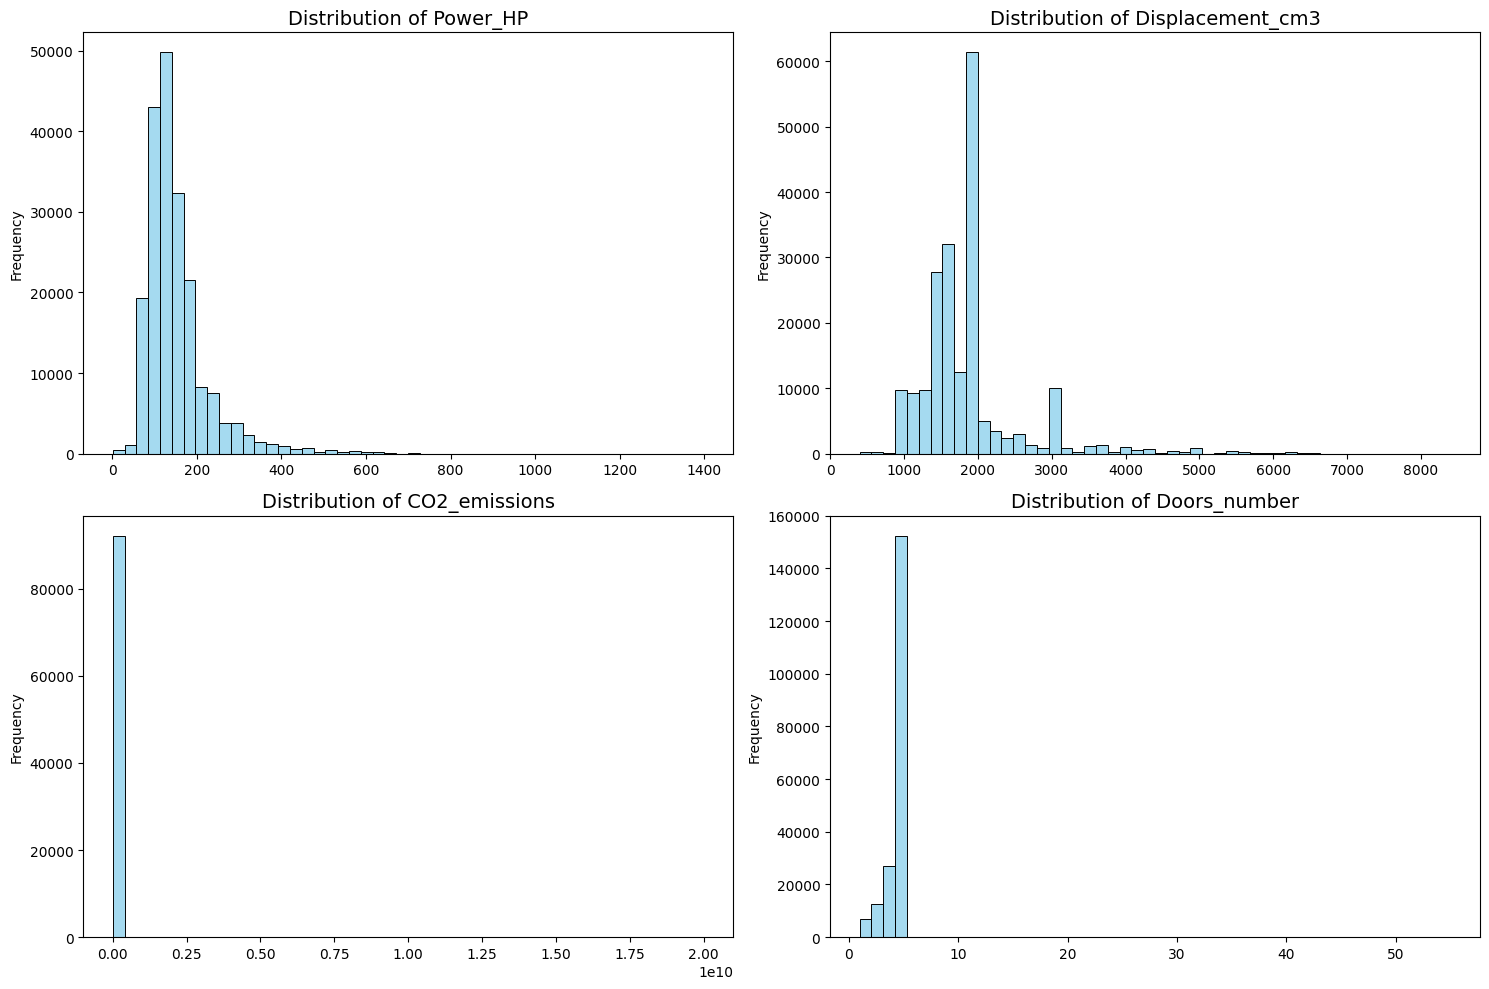

In [14]:
suspicious_columns = ['Power_HP', 'Displacement_cm3', 'CO2_emissions', 'Doors_number']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(suspicious_columns):
    sns.histplot(df_deduped[column], bins=50, ax=axes[i], kde=False, color='skyblue')
    axes[i].set_title(f'Distribution of {column}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

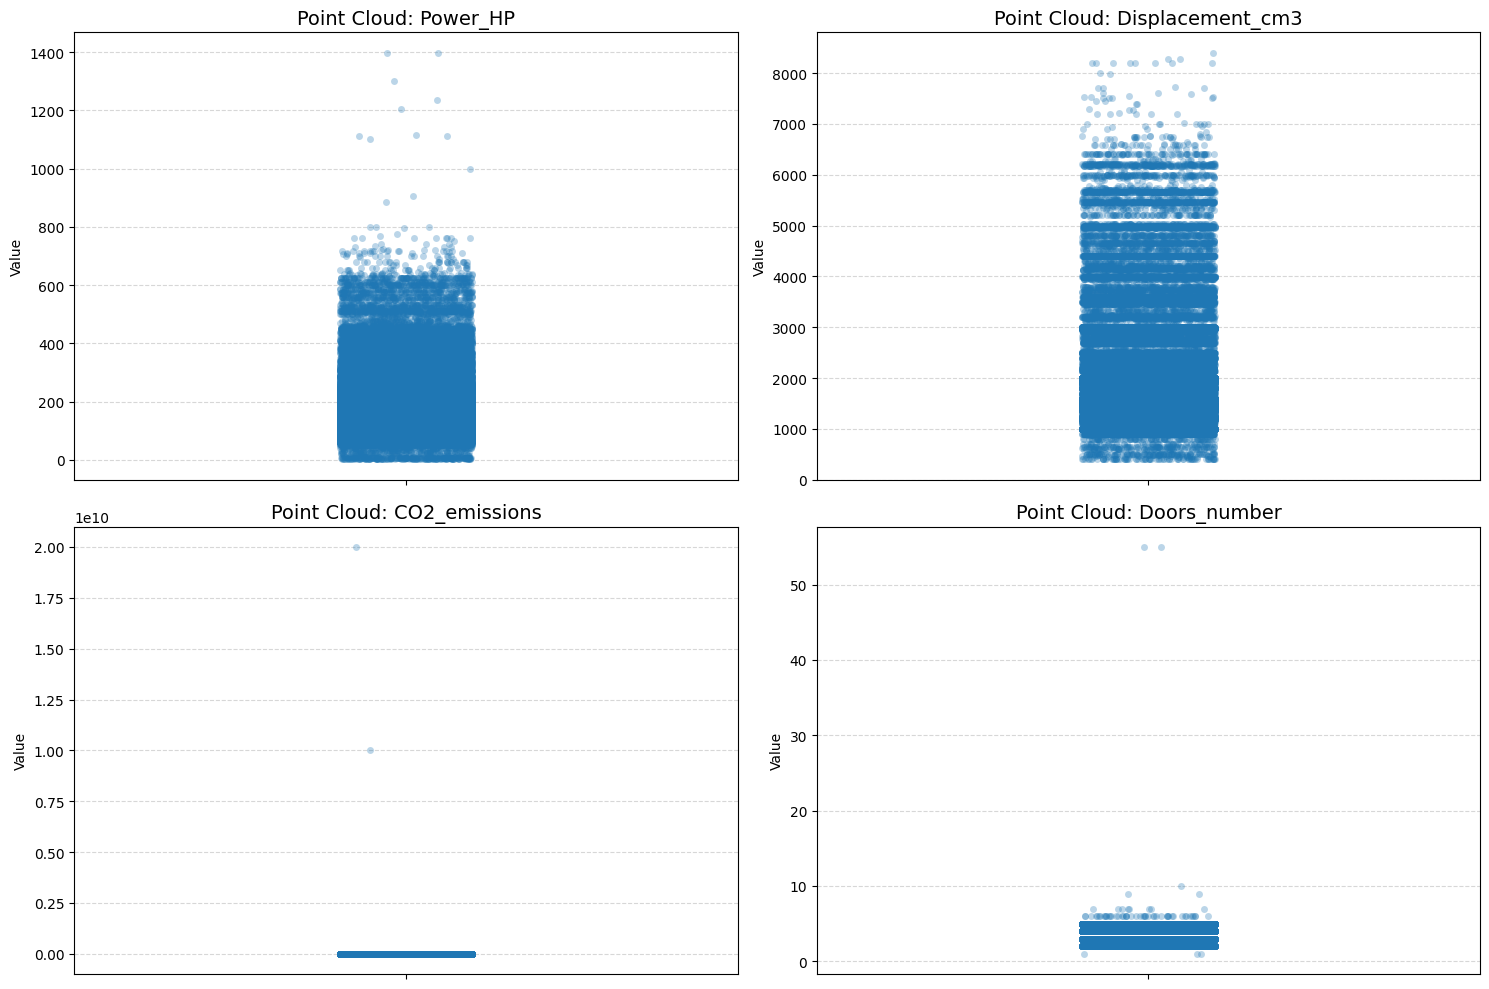

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(suspicious_columns):
    sns.stripplot(data=df_deduped, y=column, ax=axes[i], alpha=0.3, jitter=True)
    axes[i].set_title(f'Point Cloud: {column}', fontsize=14)
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Key observations:
- `Power_HP`: Retained as a numerical variable for now. However, it may be more effective to transform it into a categorical feature via binning (intervals) during the Feature Engineering phase.
- `Displacement_cm3`: Similarly, this will remain a float. Future steps will involve evaluating its distribution and potentially grouping it into engine-size categories.
- `Doors_number`: Should be treated as a categorical (discrete) variable. The number of doors is inherently non-continuous, and current visualizations suggest it behaves as a discrete factor.
- `CO2_emissions` variable seems non-informative due to many missing values and extreme outliers. I will investigate it further before deciding whether to remove or keep it.
- Data Quality: Significant outliers and entry errors (like the 55 doors) were found in all variables. These will be handled in the next sections.

### Ensure all features have the correct format: numerical columns as `float` and categorical columns as `object`

In [16]:
numerical_columns = ['Price', 'Production_year', 'Mileage_km', 'Power_HP', 'Displacement_cm3', 'CO2_emissions', 'Doors_number']
categorical_columns = df_deduped.columns.drop(numerical_columns).values.tolist()

for column in numerical_columns:
    df_deduped[column] = pd.to_numeric(df_deduped[column], errors = 'coerce')

df_deduped[categorical_columns] = df_deduped[categorical_columns].astype(object)

print(df_deduped.dtypes)

Price                        int64
Currency                    object
Condition                   object
Vehicle_brand               object
Vehicle_model               object
Vehicle_version             object
Vehicle_generation          object
Production_year              int64
Mileage_km                 float64
Power_HP                   float64
Displacement_cm3           float64
Fuel_type                   object
CO2_emissions              float64
Drive                       object
Transmission                object
Type                        object
Doors_number               float64
Colour                      object
Origin_country              object
First_owner                 object
First_registration_date     object
Offer_publication_date      object
Offer_location              object
Features                    object
dtype: object


Check if values in categorical columns are unique.

In [17]:
for column in categorical_columns:
    print(f'Feature : {column}')
    print(f'Before: {df_deduped[column].str.strip().nunique()}')
    print(f'After:{df_deduped[column].str.strip().str.lower().nunique()}')

Feature : Currency
Before: 2
After:2
Feature : Condition
Before: 2
After:2
Feature : Vehicle_brand
Before: 108
After:108
Feature : Vehicle_model
Before: 1203
After:1203
Feature : Vehicle_version
Before: 19056
After:18707
Feature : Vehicle_generation
Before: 569
After:569
Feature : Fuel_type
Before: 8
After:8
Feature : Drive
Before: 5
After:5
Feature : Transmission
Before: 2
After:2
Feature : Type
Before: 9
After:9
Feature : Colour
Before: 14
After:14
Feature : Origin_country
Before: 37
After:37
Feature : First_owner
Before: 1
After:1
Feature : First_registration_date
Before: 8438
After:8438
Feature : Offer_publication_date
Before: 41
After:41
Feature : Offer_location
Before: 13629
After:13536
Feature : Features
Before: 174002
After:174002


The biggest difference between raw and slightly transformed values is observed in case of `Vehicle_version` variable (which might be potentially "dangerous" for the model due to the big amount of unique values) and `Offer location` variable (which will be transformed during the feature engineering step)

## 6. Data Profiling & Outlier Diagnostics

#### 6.1 Data Profiling

##### 6.1.1 Numerical columns

Let's take a look at the target variable

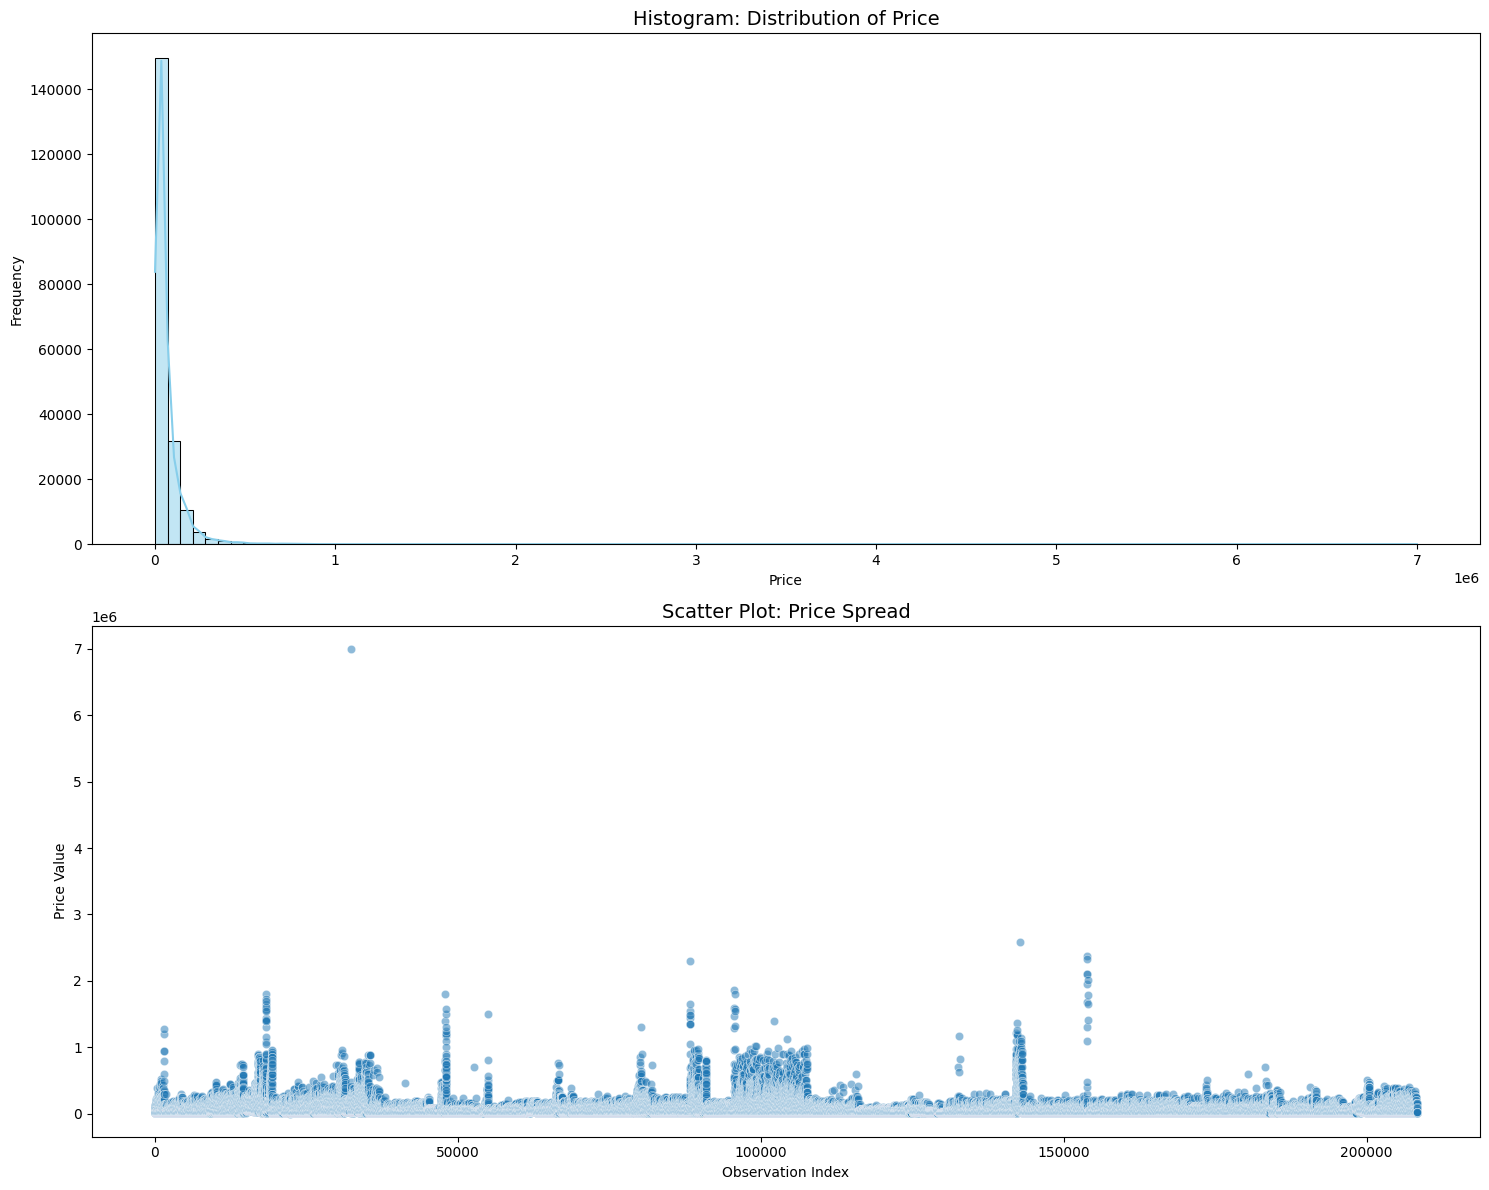

0.0


In [18]:
target = 'Price'

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12))
axes = axes.flatten()

sns.histplot(df_deduped[target], bins=100, ax=axes[0], kde=True, color='skyblue')
axes[0].set_title(f'Histogram: Distribution of {target}', fontsize=14)
axes[0].set_ylabel('Frequency')


sns.scatterplot(x=df_deduped.index, y=df_deduped[target], ax=axes[1], alpha=0.5)
axes[1].set_title(f'Scatter Plot: {target} Spread', fontsize=14)
axes[1].set_xlabel('Observation Index')
axes[1].set_ylabel('Price Value')


plt.tight_layout()
plt.show()

print(df_deduped[target].isnull().mean() * 100)

- Some ouliers are observed in the target variable, which will be investigated in the next step
- Target variable doesn't have any missing values

Let's take a look at numerical variables that weren't investigated in previous step: `Production_year` and `Milleage_km`

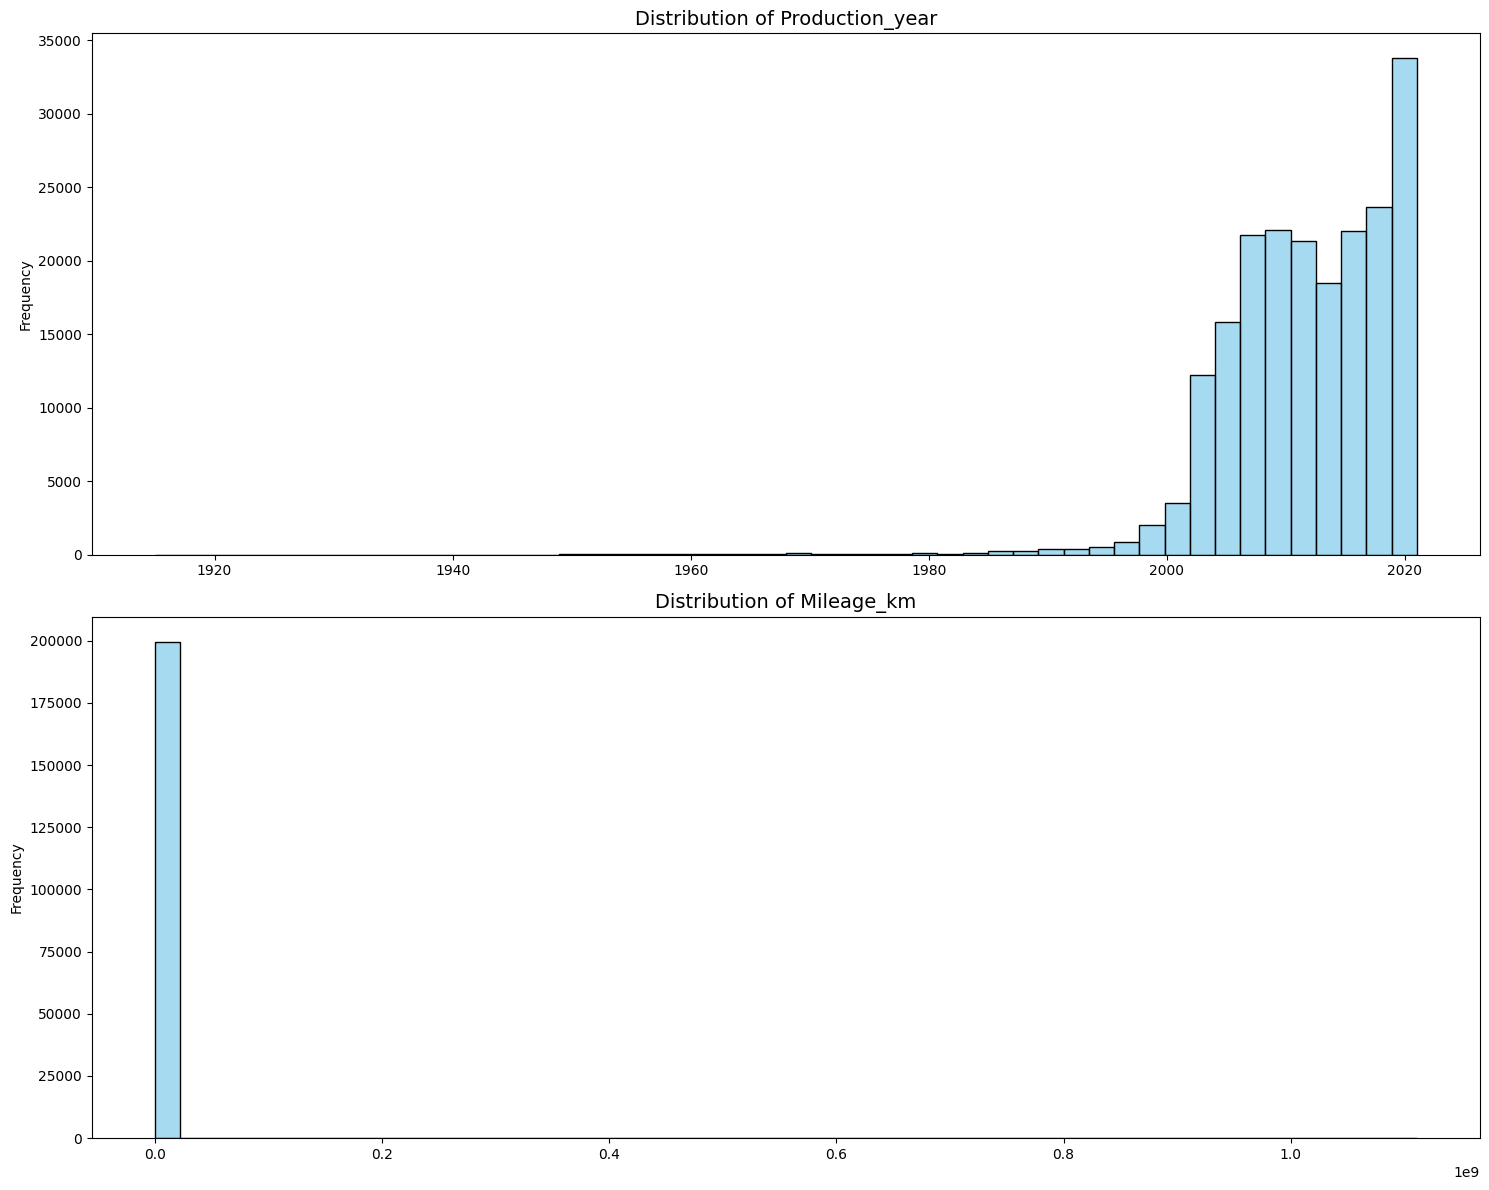

In [19]:
check_cols = ['Production_year', 'Mileage_km']

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12))
axes = axes.flatten()

for i, column in enumerate(check_cols):
    sns.histplot(df_deduped[column], bins=50, ax=axes[i], kde=False, color='skyblue')
    axes[i].set_title(f'Distribution of {column}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

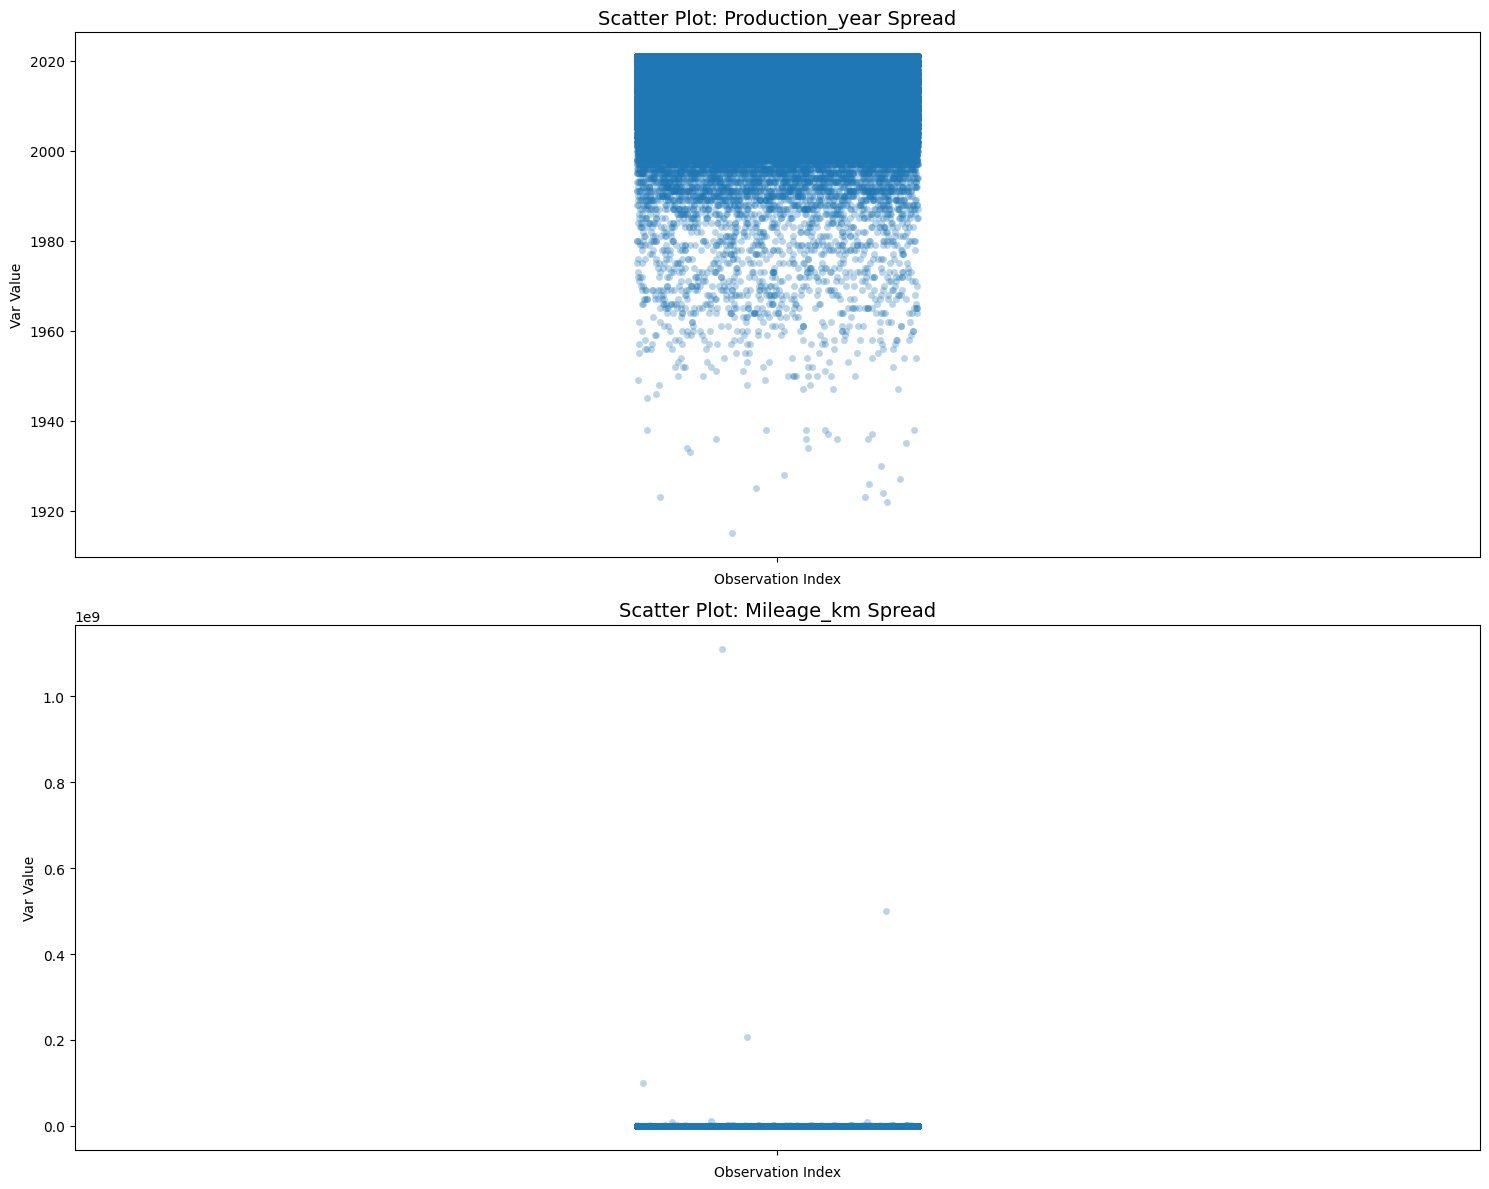

In [20]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12))
axes = axes.flatten()

for i, column in enumerate(check_cols):
    sns.stripplot(data=df_deduped, y=column, ax=axes[i], alpha=0.3, jitter=True)
    axes[i].set_title(f'Scatter Plot: {column} Spread', fontsize=14)
    axes[i].set_xlabel('Observation Index')
    axes[i].set_ylabel('Var Value')

plt.tight_layout()
plt.show()

In [21]:
print(df_deduped[check_cols].isnull().mean() * 100)

Production_year    0.000000
Mileage_km         0.367825
dtype: float64


- `Production_year` variable shows no missing values but contains several potential outliers (e.g., extreme old cars)
- `Milleage_km` feature has severe outliers and a small percentage of missing values. 
- There is a likely strong correlation between `Production_year` and `Mileage_km`, making both valuable for the model.
- Low-mileage vintage cars may represent expensive collector items rather than errors. These cases require further investigation to distinguish "data noise" from "high-value rarities."

Let's take a closer look at numerical columns statistics

In [22]:
num_stats = []

for column in numerical_columns:
    num_stats.append({
        "Feature" : column,
        "Min" : df_deduped[column].min(),
        "Max" : df_deduped[column].max(),
        "Mean" : df_deduped[column].mean(),
        "Median" : df_deduped[column].median(),
        "Mode" : df_deduped[column].mode()[0],
        "% Missing" : df_deduped[column].isnull().mean() * 100
    })

pd.options.display.float_format = '{:.2f}'.format
print(pd.DataFrame(num_stats).set_index('Feature'))

                     Min            Max      Mean    Median     Mode  \
Feature                                                                
Price             500.00     6999000.00  60215.25  34000.00 19900.00   
Production_year  1915.00        2021.00   2011.88   2012.00  2017.00   
Mileage_km          1.00  1111111111.00 152466.96 149000.00     1.00   
Power_HP            1.00        1398.00    151.48    136.00   150.00   
Displacement_cm3  400.00        8400.00   1889.09   1798.00  1598.00   
CO2_emissions       1.00 20000000000.00 325754.14    140.00   139.00   
Doors_number        1.00          55.00      4.63      5.00     5.00   

                  % Missing  
Feature                      
Price                  0.00  
Production_year        0.00  
Mileage_km             0.37  
Power_HP               0.31  
Displacement_cm3       0.89  
CO2_emissions         54.01  
Doors_number           0.67  


- There are extreme ouliers in `Mileage_km` (1.1B km), `CO2_emissions` (20B), `Doors_number` (55), `Power_HP` (1 HP), requiring hard filtering.
- Significant right-skew in `Price` is observed, which is probably caused by an outlier (7M).
- Most numerical features show high integrity (<1% missing), with the exception of `CO2_emissions` (54% missing), making it a candidate for removal.

##### 6.1.1 Categorical columns

Exclude columns `First_registration_date`, `Offer_publication_date`, `Offer_location`, `Features` because for now they can't provide useful information.

In [23]:
cat_columns = [col for col in categorical_columns if col not in ['First_registration_date','Offer_publication_date', 'Offer_location','Features']]
print(len(cat_columns))

13


Let's take a look at the top 20 values in every categorial column

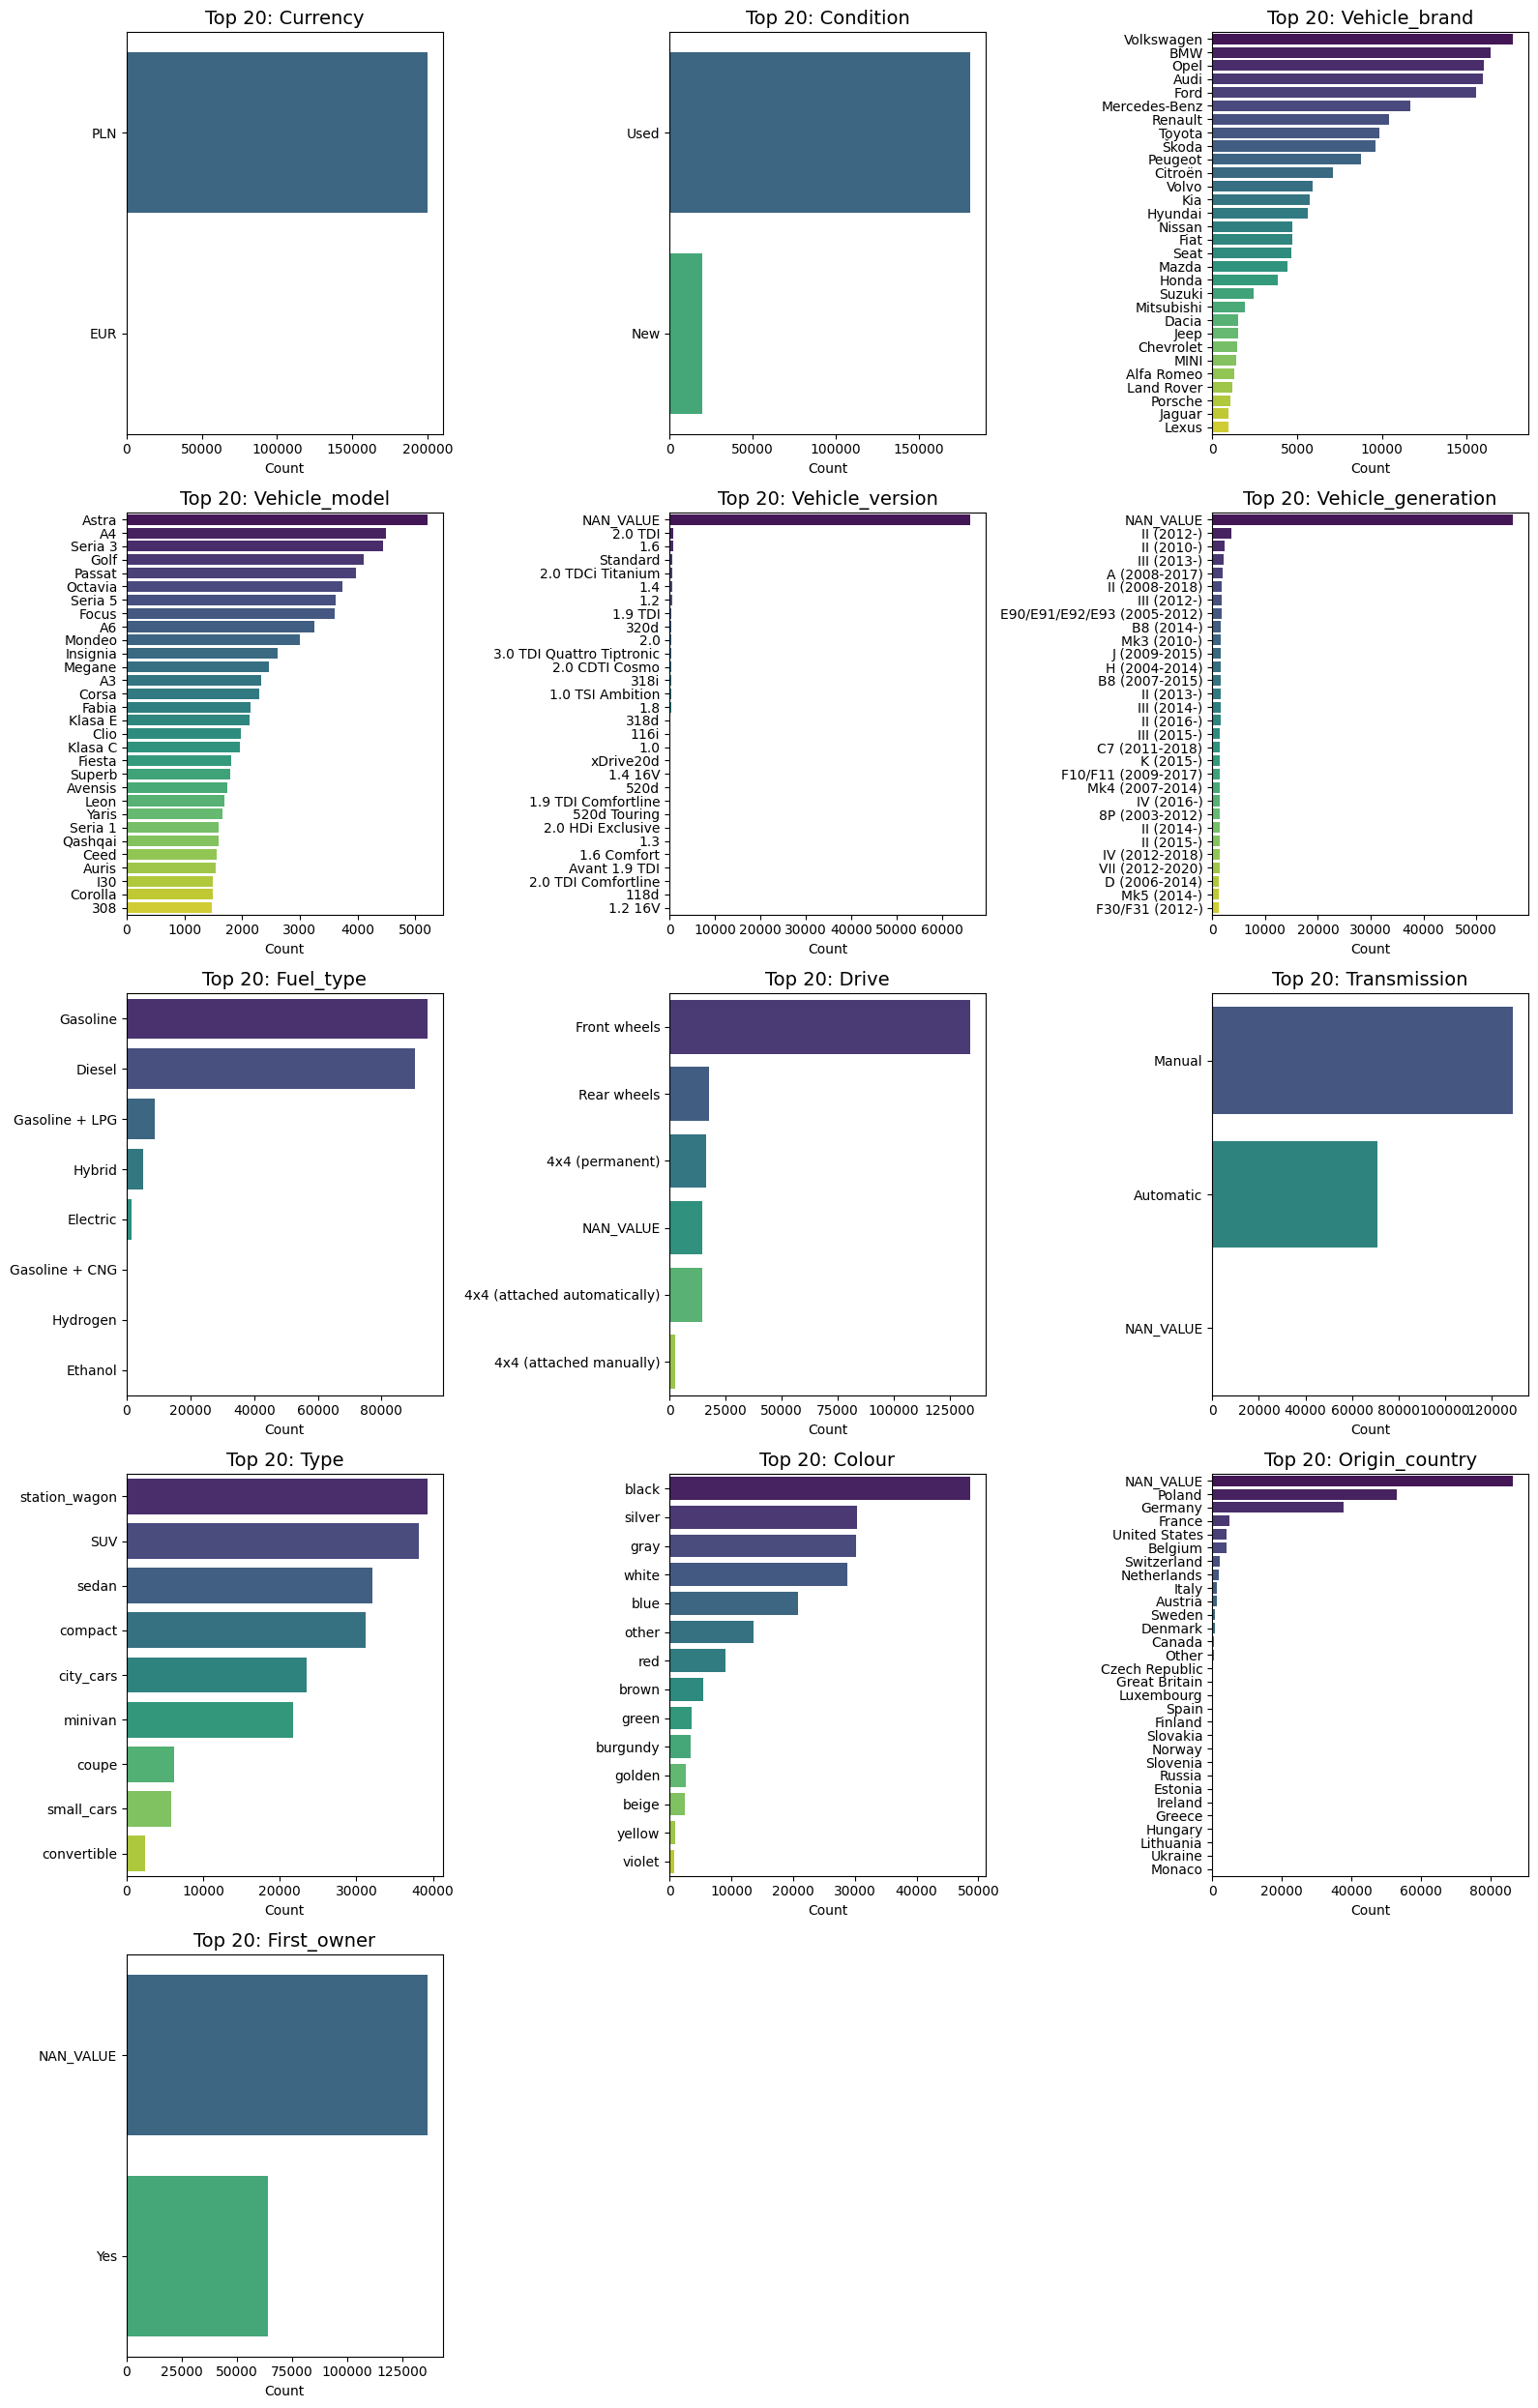

In [24]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(16, 25))
axes = axes.flatten()

for i, col in enumerate(cat_columns):
    top_values = df_deduped[col].fillna('NAN_VALUE').value_counts(dropna = False).head(30)
    
    sns.barplot(x=top_values.values, y=top_values.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top 20: {col}', fontsize=14)
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [25]:
cat_stats = []

for column in cat_columns:
    cat_stats.append({
        "Feature" : column,
        "Unique" : df_deduped[column].nunique(),
        "Missing" : df_deduped[column].isnull().mean() * 100,
        "Mode %" : df_deduped[column].value_counts(dropna=False).iloc[0] / len(df_deduped) * 100,
        "Rare count" : ((df_deduped[column].value_counts(dropna=False) / len(df_deduped)) < 0.02).sum()
        
    })

pd.options.display.float_format = '{:.2f}'.format
print(pd.DataFrame(cat_stats).set_index('Feature'))

                    Unique  Missing  Mode %  Rare count
Feature                                                
Currency                 2     0.00   99.88           1
Condition                2     0.00   90.26           0
Vehicle_brand          108     0.00    8.86          90
Vehicle_model         1203     0.00    2.60        1199
Vehicle_version      19056    33.04   33.04       19056
Vehicle_generation     569    28.46   28.46         569
Fuel_type                8     0.00   47.16           4
Drive                    5     7.38   67.07           1
Transmission             2     0.23   64.47           1
Type                     9     0.00   19.62           1
Colour                  14     0.00   24.32           6
Origin_country          37    43.25   43.25          32
First_owner              1    68.09   68.09           0


- Features like `Vehicle_model`, `Vehicle_version`, and `Vehicle_generation` possess a very high number of unique values and rare labels. This could introduce significant noise and negatively impact the model’s generalization ability.

- A high percentage of missing values is observed in `Origin_country` (43%) and `First_owner` (68%). However, the "missingness" itself could be informative. These variables require careful investigation during the imputation/handling step.

#### 6.2 Outlier Diagnostics

n the first step, impossible values are removed from the dataset to allow for a better assessment of variable distributions

In [31]:
df_filtered = df_deduped[
    (df_deduped['Power_HP'] >= 8) &              # Because the lowest amount of HP in a car is around 8 HP
    (df_deduped['Mileage_km'] <= 1000000) &      # Assume there are long lasting cars
    (df_deduped['Doors_number'] <= 10) &         # Safely assume there are vehicles with up to 10 doors
    (df_deduped['CO2_emissions'] <= 1000000)     # Values > 1M might be a system error
].copy()

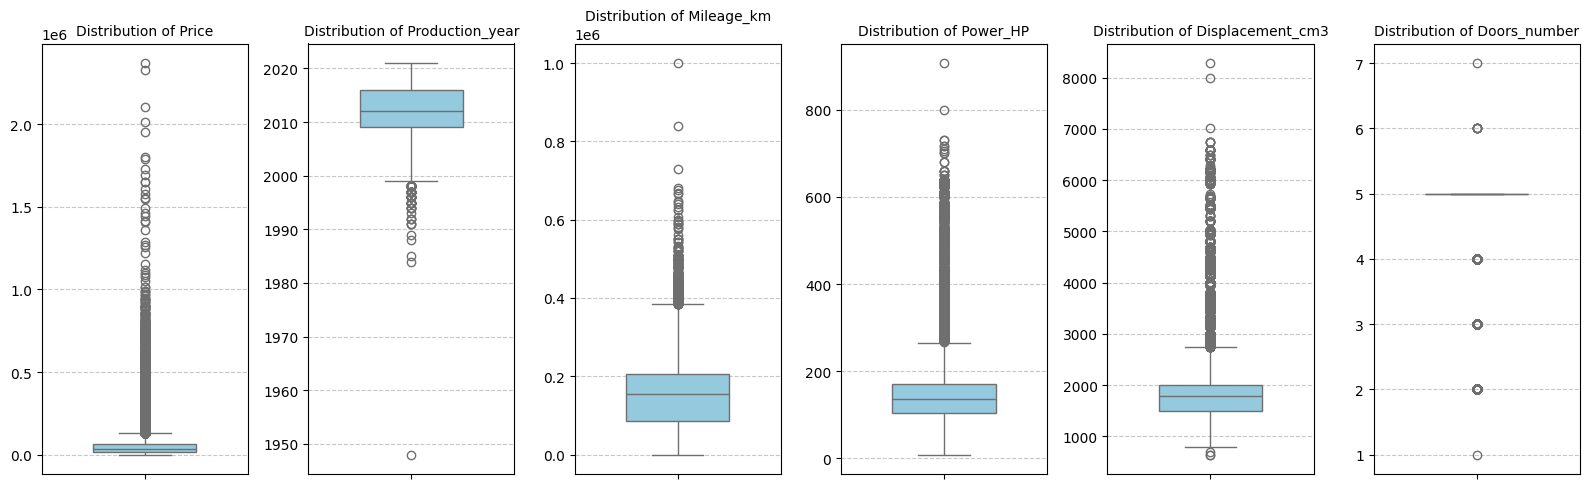

In [43]:
n_cols = len(numerical_columns) - 1
fig, axes = plt.subplots(nrows=1, ncols=n_cols, figsize=(16, 5))

for i, col in enumerate(c for c in numerical_columns if c not in ['CO2_emissions']): # `CO2_emissions` is excluded due to high percentage of missing values and extreme data noise
    sns.boxplot(y=df_filtered[col], ax=axes[i], color='skyblue', width=0.5) 
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_ylabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

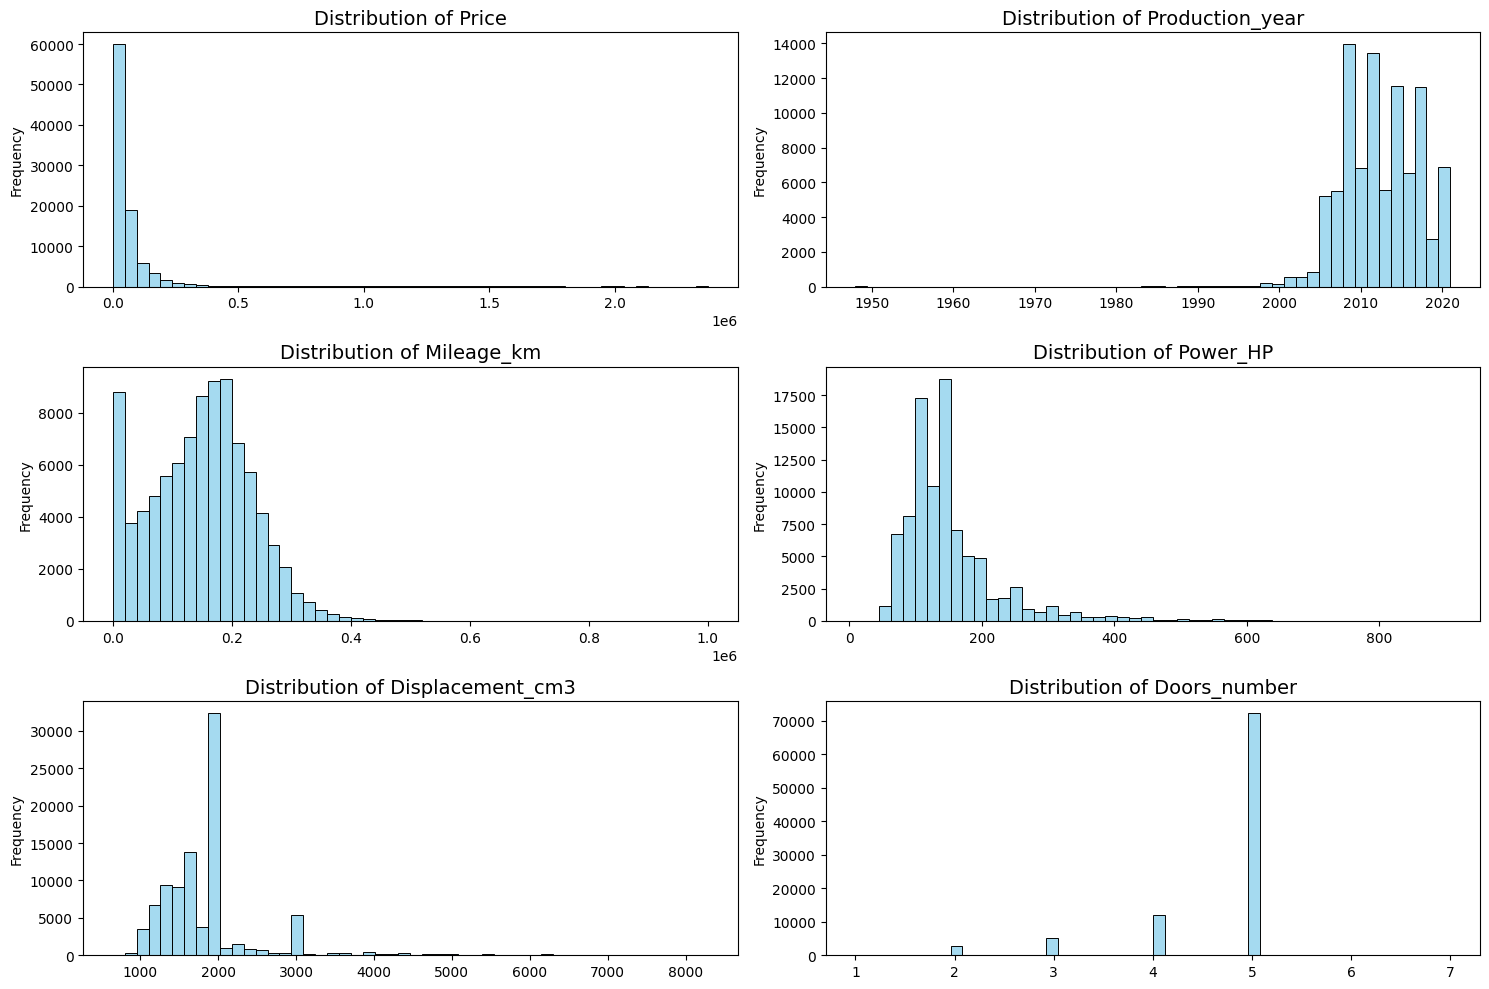

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(c for c in numerical_columns if c not in ['CO2_emissions', 'Doors_number']):
    sns.histplot(df_filtered[column], bins=50, ax=axes[i], kde=False, color='skyblue')
    axes[i].set_title(f'Distribution of {column}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [47]:
num_out_stats = []

for column in [c for c in numerical_columns if c not in ['CO2_emissions']]:
    num_out_stats.append({
        "Feature" : column,
        "Min" : df_filtered[column].min(),
        "Max" : df_filtered[column].max(),
        "Mean" : df_filtered[column].mean(),
        "Median" : df_filtered[column].median(),
        "Mode" : df_filtered[column].mode()[0],
        "% Missing" : df_filtered[column].isnull().mean() * 100
        
    })

pd.options.display.float_format = '{:.2f}'.format
print(pd.DataFrame(num_out_stats).set_index('Feature'))

                     Min        Max      Mean    Median     Mode  % Missing
Feature                                                                    
Price             599.00 2370000.00  57460.50  33900.00 19900.00       0.00
Production_year  1948.00    2021.00   2012.52   2012.00  2011.00       0.00
Mileage_km          1.00  999999.00 148473.56 154000.00     1.00       0.00
Power_HP            9.00     907.00    152.00    136.00   150.00       0.00
Displacement_cm3  647.00    8285.00   1869.80   1798.00  1598.00       0.03
Doors_number        1.00       7.00      4.67      5.00     5.00       0.00


Considering severe skewness of variables and non-normal distributions, the **IQR** method is selected for the outlier detection. This method is more robust and less sensitive to extreme values than standard deviation-based rules.

In [58]:
outlier_idx = set()

for column in [c for c in numerical_columns if c not in ['CO2_emissions']]:
    valid_data = df_filtered[column].dropna()
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_idx.update(valid_data[(valid_data < lower_bound) | 
                              (valid_data > upper_bound)].index)

print(len(outlier_idx) / len(valid_data) * 100)


31.827606795853008


#### Outlier Analysis & Strategy

The IQR-based outlier detection identified more than 30% of the dataset as potential anomalies. Removing such a significant portion would lead to a substantial loss of valuable information regarding distinct market segments (e.g. vintage cars, showroom vehicles, supercars etc.)

Forcing this non-linear reality into a normal distribution by removing or capping these points would distort the model's ability to recognize real-world diversity. Therefore, no statistical outliers will be removed at this stage. Only physically impossible values (e.g., 55 doors or 20B CO2 emissions) were excluded to maintain data integrity.

This high percentage of outliers and the complex nature of the data serve as a strong argument for using tree-based algorithms (e.g., Random Forest, XGBoost) during the modeling phase. These models natively handle non-linear interactions and are robust to extreme values.

## 7. Missing Values